<a href="https://colab.research.google.com/github/joolsa/PersonaBase/blob/main/Notebooks/PE02a_Persona_diversity_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🎭 PERSONA DIVERSITY MEASUREMENT EXERCISE

📋 Generating persona sets...

👥 PERSONA SETS:

Low Diversity:
 persona_id  age gender        occupation  income  education location  tech_savvy
          1   28   Male Software Engineer 80-120k Bachelor's    Urban           4
          2   29   Male Software Engineer 80-120k Bachelor's    Urban           4
          3   30   Male Software Engineer  50-80k Bachelor's    Urban           5
          4   27   Male          Designer 80-120k Bachelor's    Urban           4
          5   31 Female Software Engineer 80-120k   Master's    Urban           4

Medium Diversity:
 persona_id  age gender        occupation  income  education location  tech_savvy
          1   25 Female           Teacher  30-50k   Master's Suburban           2
          2   35   Male Software Engineer 80-120k Bachelor's    Urban           4
          3   42 Female            Doctor   >120k        PhD    Urban           3
          4   28   Male            Artist    <30k Bachelo

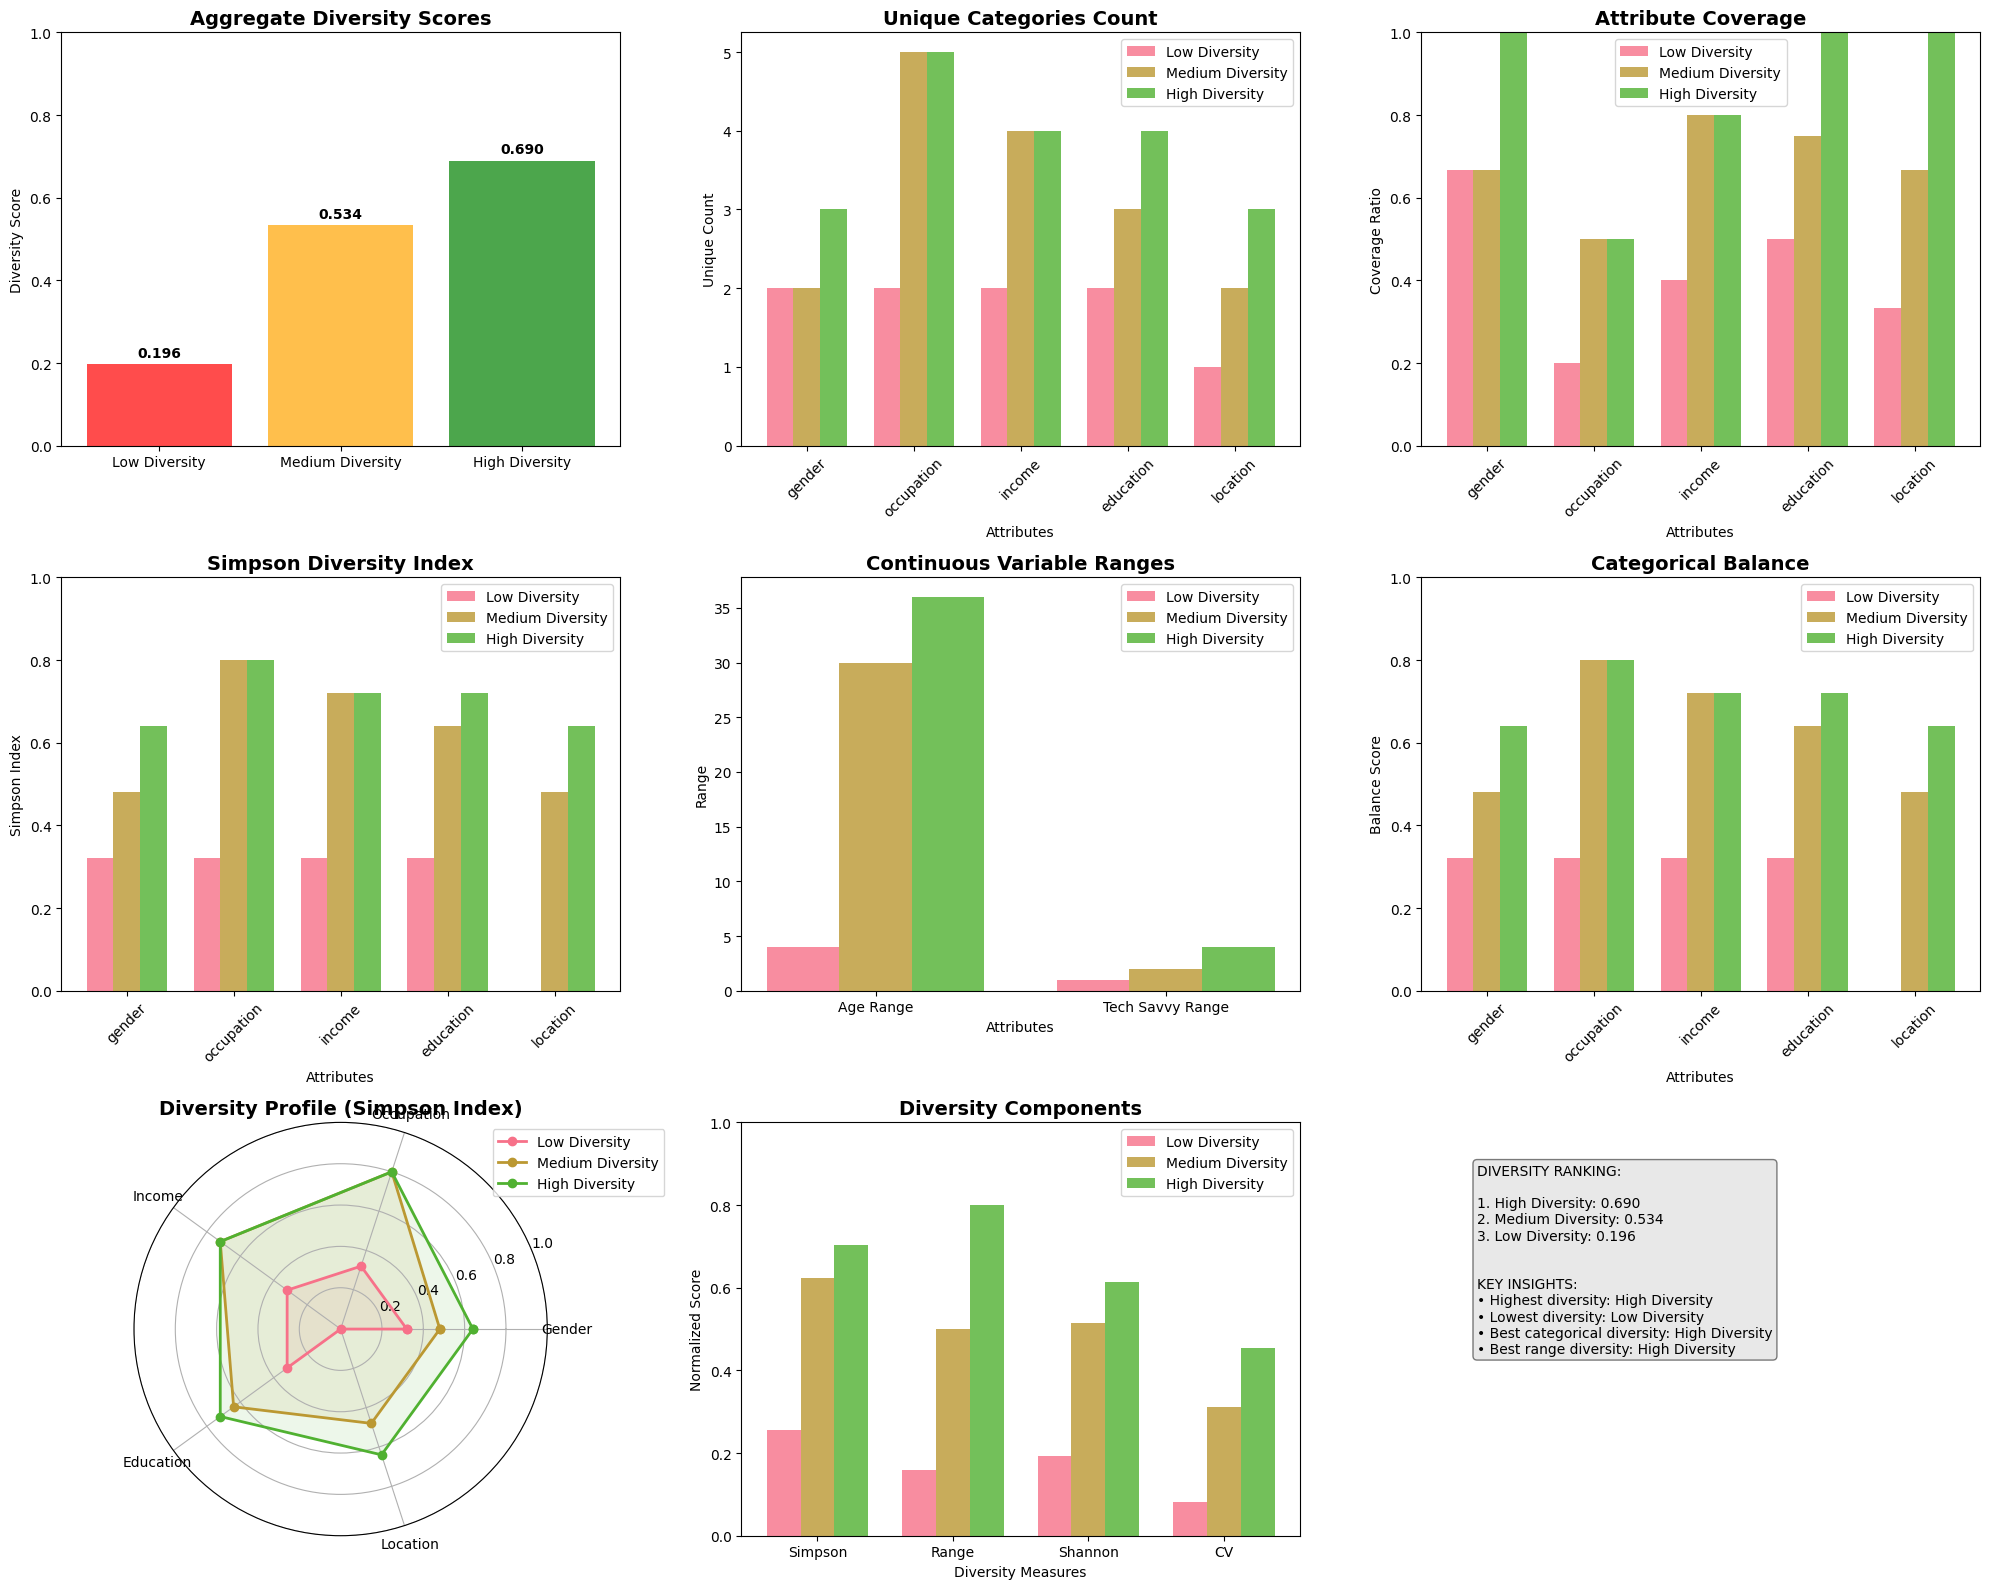


✅ Analysis complete! The visualizations show:
   • Aggregate diversity scores for comparison
   • Breakdown of diversity across different attributes
   • Coverage and balance analysis
   • Component-wise diversity scores
   • Overall diversity profiles


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

class PersonaDiversityAnalyzer:
    def __init__(self):
        self.categorical_attributes = ['gender', 'occupation', 'income', 'education', 'location']
        self.continuous_attributes = ['age', 'tech_savvy']
        self.binary_attributes = ['gender']  # Can be treated as binary for balance analysis

    def generate_persona_sets(self):
        """Generate three persona sets with different diversity levels"""

        # Define possible values for each attribute
        genders = ['Male', 'Female', 'Non-binary']
        occupations = ['Software Engineer', 'Teacher', 'Doctor', 'Artist', 'Manager',
                      'Student', 'Entrepreneur', 'Nurse', 'Designer', 'Analyst']
        incomes = ['<30k', '30-50k', '50-80k', '80-120k', '>120k']
        educations = ['High School', 'Bachelor\'s', 'Master\'s', 'PhD']
        locations = ['Urban', 'Suburban', 'Rural']

        persona_sets = {}

        # Low Diversity Set - mostly similar profiles
        low_diversity = pd.DataFrame({
            'persona_id': range(1, 6),
            'age': [28, 29, 30, 27, 31],
            'gender': ['Male', 'Male', 'Male', 'Male', 'Female'],
            'occupation': ['Software Engineer', 'Software Engineer', 'Software Engineer', 'Designer', 'Software Engineer'],
            'income': ['80-120k', '80-120k', '50-80k', '80-120k', '80-120k'],
            'education': ['Bachelor\'s', 'Bachelor\'s', 'Bachelor\'s', 'Bachelor\'s', 'Master\'s'],
            'location': ['Urban', 'Urban', 'Urban', 'Urban', 'Urban'],
            'tech_savvy': [4, 4, 5, 4, 4]
        })

        # Medium Diversity Set - moderate variation
        medium_diversity = pd.DataFrame({
            'persona_id': range(1, 6),
            'age': [25, 35, 42, 28, 55],
            'gender': ['Female', 'Male', 'Female', 'Male', 'Female'],
            'occupation': ['Teacher', 'Software Engineer', 'Doctor', 'Artist', 'Manager'],
            'income': ['30-50k', '80-120k', '>120k', '<30k', '80-120k'],
            'education': ['Master\'s', 'Bachelor\'s', 'PhD', 'Bachelor\'s', 'Master\'s'],
            'location': ['Suburban', 'Urban', 'Urban', 'Urban', 'Suburban'],
            'tech_savvy': [2, 4, 3, 3, 2]
        })

        # High Diversity Set - maximum variation
        high_diversity = pd.DataFrame({
            'persona_id': range(1, 6),
            'age': [22, 45, 33, 58, 29],
            'gender': ['Non-binary', 'Female', 'Male', 'Female', 'Male'],
            'occupation': ['Student', 'Doctor', 'Entrepreneur', 'Nurse', 'Artist'],
            'income': ['<30k', '>120k', '50-80k', '50-80k', '30-50k'],
            'education': ['High School', 'PhD', 'Bachelor\'s', 'Bachelor\'s', 'Master\'s'],
            'location': ['Rural', 'Urban', 'Suburban', 'Rural', 'Urban'],
            'tech_savvy': [3, 2, 5, 1, 4]
        })

        return {
            'Low Diversity': low_diversity,
            'Medium Diversity': medium_diversity,
            'High Diversity': high_diversity
        }

    def calculate_absolute_diversity_metrics(self, df):
        """Calculate absolute diversity measures"""
        metrics = {}

        # Unique category counts
        for attr in self.categorical_attributes:
            metrics[f'unique_{attr}'] = df[attr].nunique()

        # Ranges for continuous variables
        metrics['age_range'] = df['age'].max() - df['age'].min()
        metrics['tech_savvy_range'] = df['tech_savvy'].max() - df['tech_savvy'].min()

        # Coverage metrics (percentage of possible categories covered)
        possible_counts = {
            'gender': 3, 'occupation': 10, 'income': 5,
            'education': 4, 'location': 3
        }

        for attr in ['gender', 'occupation', 'income', 'education', 'location']:
            coverage = df[attr].nunique() / possible_counts[attr]
            metrics[f'{attr}_coverage'] = coverage

        # Balance metrics (for binary/few category variables)
        # Gender balance - closer to even distribution = higher diversity
        gender_counts = df['gender'].value_counts(normalize=True)
        # Calculate evenness using 1 - sum of squared proportions
        gender_balance = 1 - sum(gender_counts ** 2)
        metrics['gender_balance'] = gender_balance

        # Overall categorical balance
        all_balances = []
        for attr in self.categorical_attributes:
            counts = df[attr].value_counts(normalize=True)
            balance = 1 - sum(counts ** 2)
            all_balances.append(balance)
            metrics[f'{attr}_balance'] = balance

        metrics['average_categorical_balance'] = np.mean(all_balances)

        return metrics

    def calculate_relative_diversity_metrics(self, df):
        """Calculate relative diversity measures (normalized 0-1 scores)"""
        metrics = {}

        # Simpson's Diversity Index for categorical variables
        def simpson_diversity(series):
            counts = series.value_counts(normalize=True)
            return 1 - sum(counts ** 2)

        for attr in self.categorical_attributes:
            metrics[f'{attr}_simpson'] = simpson_diversity(df[attr])

        # Shannon Diversity Index (alternative measure)
        def shannon_diversity(series):
            counts = series.value_counts(normalize=True)
            return entropy(counts, base=2)

        for attr in self.categorical_attributes:
            metrics[f'{attr}_shannon'] = shannon_diversity(df[attr])

        # Normalized range diversity for continuous variables
        # Normalize by theoretical maximum ranges
        max_age_range = 60  # Reasonable max age range for personas
        max_tech_range = 4  # 1-5 scale, so max range is 4

        age_range = df['age'].max() - df['age'].min()
        tech_range = df['tech_savvy'].max() - df['tech_savvy'].min()

        metrics['age_normalized_range'] = age_range / max_age_range
        metrics['tech_savvy_normalized_range'] = tech_range / max_tech_range

        # Coefficient of Variation (CV) for continuous variables
        metrics['age_cv'] = df['age'].std() / df['age'].mean() if df['age'].mean() > 0 else 0
        metrics['tech_savvy_cv'] = df['tech_savvy'].std() / df['tech_savvy'].mean() if df['tech_savvy'].mean() > 0 else 0

        return metrics

    def calculate_aggregate_diversity_score(self, df):
        """Calculate a single aggregate diversity score"""
        rel_metrics = self.calculate_relative_diversity_metrics(df)

        # Define weights for different aspects of diversity
        weights = {
            'categorical_simpson': 0.4,  # Weight for categorical diversity
            'continuous_range': 0.3,     # Weight for continuous variable ranges
            'categorical_shannon': 0.2,  # Alternative categorical measure
            'continuous_cv': 0.1         # Coefficient of variation
        }

        # Aggregate categorical Simpson scores
        simpson_scores = [
            rel_metrics['gender_simpson'],
            rel_metrics['occupation_simpson'],
            rel_metrics['income_simpson'],
            rel_metrics['education_simpson'],
            rel_metrics['location_simpson']
        ]
        avg_simpson = np.mean(simpson_scores)

        # Aggregate continuous range scores
        range_scores = [
            rel_metrics['age_normalized_range'],
            rel_metrics['tech_savvy_normalized_range']
        ]
        avg_range = np.mean(range_scores)

        # Aggregate Shannon scores
        shannon_scores = [
            rel_metrics['gender_shannon'],
            rel_metrics['occupation_shannon'],
            rel_metrics['income_shannon'],
            rel_metrics['education_shannon'],
            rel_metrics['location_shannon']
        ]
        avg_shannon = np.mean(shannon_scores)

        # Aggregate CV scores
        cv_scores = [
            rel_metrics['age_cv'],
            rel_metrics['tech_savvy_cv']
        ]
        avg_cv = np.mean(cv_scores)

        # Calculate weighted aggregate score
        aggregate_score = (
            weights['categorical_simpson'] * avg_simpson +
            weights['continuous_range'] * avg_range +
            weights['categorical_shannon'] * (avg_shannon / 3) +  # Normalize Shannon (max ~3 for our categories)
            weights['continuous_cv'] * min(avg_cv, 1)  # Cap CV at 1 for normalization
        )

        return {
            'aggregate_diversity_score': aggregate_score,
            'avg_simpson_diversity': avg_simpson,
            'avg_range_diversity': avg_range,
            'avg_shannon_diversity': avg_shannon,
            'avg_cv_diversity': avg_cv
        }

    def create_comprehensive_report(self, persona_sets):
        """Create a comprehensive diversity analysis report"""

        # Calculate metrics for each set
        all_results = {}

        for set_name, df in persona_sets.items():
            abs_metrics = self.calculate_absolute_diversity_metrics(df)
            rel_metrics = self.calculate_relative_diversity_metrics(df)
            agg_metrics = self.calculate_aggregate_diversity_score(df)

            all_results[set_name] = {
                'absolute': abs_metrics,
                'relative': rel_metrics,
                'aggregate': agg_metrics,
                'dataframe': df
            }

        return all_results

    def visualize_diversity_comparison(self, results):
        """Create comprehensive visualizations comparing diversity across sets"""

        # Setup the plotting area
        fig = plt.figure(figsize=(20, 16))

        # 1. Aggregate Diversity Scores Comparison
        plt.subplot(3, 3, 1)
        set_names = list(results.keys())
        agg_scores = [results[name]['aggregate']['aggregate_diversity_score'] for name in set_names]

        bars = plt.bar(set_names, agg_scores, color=['red', 'orange', 'green'], alpha=0.7)
        plt.title('Aggregate Diversity Scores', fontsize=14, fontweight='bold')
        plt.ylabel('Diversity Score')
        plt.ylim(0, 1)

        # Add value labels on bars
        for bar, score in zip(bars, agg_scores):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

        # 2. Unique Categories Count
        plt.subplot(3, 3, 2)
        categories = ['gender', 'occupation', 'income', 'education', 'location']
        x = np.arange(len(categories))
        width = 0.25

        for i, set_name in enumerate(set_names):
            counts = [results[set_name]['absolute'][f'unique_{cat}'] for cat in categories]
            plt.bar(x + i*width, counts, width, label=set_name, alpha=0.8)

        plt.title('Unique Categories Count', fontsize=14, fontweight='bold')
        plt.xlabel('Attributes')
        plt.ylabel('Unique Count')
        plt.xticks(x + width, categories, rotation=45)
        plt.legend()

        # 3. Coverage Analysis
        plt.subplot(3, 3, 3)
        coverage_data = []
        for set_name in set_names:
            coverage = [results[set_name]['absolute'][f'{cat}_coverage'] for cat in categories]
            coverage_data.append(coverage)

        x = np.arange(len(categories))
        for i, (set_name, coverage) in enumerate(zip(set_names, coverage_data)):
            plt.bar(x + i*width, coverage, width, label=set_name, alpha=0.8)

        plt.title('Attribute Coverage', fontsize=14, fontweight='bold')
        plt.xlabel('Attributes')
        plt.ylabel('Coverage Ratio')
        plt.xticks(x + width, categories, rotation=45)
        plt.legend()
        plt.ylim(0, 1)

        # 4. Simpson Diversity Index Comparison
        plt.subplot(3, 3, 4)
        simpson_data = []
        for set_name in set_names:
            simpson = [results[set_name]['relative'][f'{cat}_simpson'] for cat in categories]
            simpson_data.append(simpson)

        x = np.arange(len(categories))
        for i, (set_name, simpson) in enumerate(zip(set_names, simpson_data)):
            plt.bar(x + i*width, simpson, width, label=set_name, alpha=0.8)

        plt.title('Simpson Diversity Index', fontsize=14, fontweight='bold')
        plt.xlabel('Attributes')
        plt.ylabel('Simpson Index')
        plt.xticks(x + width, categories, rotation=45)
        plt.legend()
        plt.ylim(0, 1)

        # 5. Age and Tech Savvy Ranges
        plt.subplot(3, 3, 5)
        range_attrs = ['age_range', 'tech_savvy_range']
        range_data = []
        for set_name in set_names:
            ranges = [results[set_name]['absolute'][attr] for attr in range_attrs]
            range_data.append(ranges)

        x = np.arange(len(range_attrs))
        for i, (set_name, ranges) in enumerate(zip(set_names, range_data)):
            plt.bar(x + i*width, ranges, width, label=set_name, alpha=0.8)

        plt.title('Continuous Variable Ranges', fontsize=14, fontweight='bold')
        plt.xlabel('Attributes')
        plt.ylabel('Range')
        plt.xticks(x + width, ['Age Range', 'Tech Savvy Range'])
        plt.legend()

        # 6. Balance Metrics
        plt.subplot(3, 3, 6)
        balance_data = []
        for set_name in set_names:
            balance = [results[set_name]['absolute'][f'{cat}_balance'] for cat in categories]
            balance_data.append(balance)

        x = np.arange(len(categories))
        for i, (set_name, balance) in enumerate(zip(set_names, balance_data)):
            plt.bar(x + i*width, balance, width, label=set_name, alpha=0.8)

        plt.title('Categorical Balance', fontsize=14, fontweight='bold')
        plt.xlabel('Attributes')
        plt.ylabel('Balance Score')
        plt.xticks(x + width, categories, rotation=45)
        plt.legend()
        plt.ylim(0, 1)

        # 7. Radar Chart for Overall Diversity Profile
        plt.subplot(3, 3, 7, projection='polar')

        # Prepare data for radar chart
        attributes = ['Gender', 'Occupation', 'Income', 'Education', 'Location']
        angles = np.linspace(0, 2*np.pi, len(attributes), endpoint=False).tolist()
        angles += angles[:1]  # Complete the circle

        for set_name in set_names:
            values = [results[set_name]['relative'][f'{cat.lower()}_simpson'] for cat in attributes]
            values += values[:1]  # Complete the circle

            plt.plot(angles, values, 'o-', linewidth=2, label=set_name)
            plt.fill(angles, values, alpha=0.1)

        plt.xticks(angles[:-1], attributes)
        plt.ylim(0, 1)
        plt.title('Diversity Profile (Simpson Index)', fontsize=14, fontweight='bold')
        plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

        # 8. Component Breakdown of Aggregate Score
        plt.subplot(3, 3, 8)
        components = ['avg_simpson_diversity', 'avg_range_diversity', 'avg_shannon_diversity', 'avg_cv_diversity']
        component_labels = ['Simpson', 'Range', 'Shannon', 'CV']

        x = np.arange(len(components))
        for i, set_name in enumerate(set_names):
            values = [results[set_name]['aggregate'][comp] for comp in components]
            # Normalize Shannon and CV for better comparison
            values[2] = values[2] / 3  # Normalize Shannon
            values[3] = min(values[3], 1)  # Cap CV
            plt.bar(x + i*width, values, width, label=set_name, alpha=0.8)

        plt.title('Diversity Components', fontsize=14, fontweight='bold')
        plt.xlabel('Diversity Measures')
        plt.ylabel('Normalized Score')
        plt.xticks(x + width, component_labels)
        plt.legend()
        plt.ylim(0, 1)

        # 9. Summary Statistics Table (as text)
        plt.subplot(3, 3, 9)
        plt.axis('off')

        summary_text = "DIVERSITY RANKING:\n\n"
        ranked_sets = sorted(set_names, key=lambda x: results[x]['aggregate']['aggregate_diversity_score'], reverse=True)

        for i, set_name in enumerate(ranked_sets):
            score = results[set_name]['aggregate']['aggregate_diversity_score']
            summary_text += f"{i+1}. {set_name}: {score:.3f}\n"

        summary_text += "\n\nKEY INSIGHTS:\n"
        summary_text += f"• Highest diversity: {ranked_sets[0]}\n"
        summary_text += f"• Lowest diversity: {ranked_sets[-1]}\n"

        # Find best performing attributes
        best_simpson = max(set_names, key=lambda x: results[x]['aggregate']['avg_simpson_diversity'])
        best_range = max(set_names, key=lambda x: results[x]['aggregate']['avg_range_diversity'])

        summary_text += f"• Best categorical diversity: {best_simpson}\n"
        summary_text += f"• Best range diversity: {best_range}"

        plt.text(0.1, 0.9, summary_text, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.5))

        plt.tight_layout()
        plt.show()

    def print_detailed_metrics(self, results):
        """Print detailed metrics for each persona set"""

        for set_name, data in results.items():
            print(f"\n{'='*60}")
            print(f"DETAILED METRICS FOR {set_name.upper()}")
            print(f"{'='*60}")

            print(f"\n📊 AGGREGATE DIVERSITY SCORE: {data['aggregate']['aggregate_diversity_score']:.3f}")

            print(f"\n📈 ABSOLUTE METRICS:")
            abs_metrics = data['absolute']
            print(f"  • Unique Categories:")
            for attr in ['gender', 'occupation', 'income', 'education', 'location']:
                print(f"    - {attr.title()}: {abs_metrics[f'unique_{attr}']}")

            print(f"  • Ranges:")
            print(f"    - Age: {abs_metrics['age_range']} years")
            print(f"    - Tech Savvy: {abs_metrics['tech_savvy_range']} points")

            print(f"  • Coverage (% of possible categories):")
            for attr in ['gender', 'occupation', 'income', 'education', 'location']:
                coverage = abs_metrics[f'{attr}_coverage'] * 100
                print(f"    - {attr.title()}: {coverage:.1f}%")

            print(f"  • Balance Scores:")
            for attr in ['gender', 'occupation', 'income', 'education', 'location']:
                balance = abs_metrics[f'{attr}_balance']
                print(f"    - {attr.title()}: {balance:.3f}")

            print(f"\n📊 RELATIVE METRICS:")
            rel_metrics = data['relative']
            print(f"  • Simpson Diversity Index:")
            for attr in ['gender', 'occupation', 'income', 'education', 'location']:
                simpson = rel_metrics[f'{attr}_simpson']
                print(f"    - {attr.title()}: {simpson:.3f}")

            print(f"  • Normalized Ranges:")
            print(f"    - Age: {rel_metrics['age_normalized_range']:.3f}")
            print(f"    - Tech Savvy: {rel_metrics['tech_savvy_normalized_range']:.3f}")

            print(f"\n🎯 COMPONENT SCORES:")
            agg_data = data['aggregate']
            print(f"  • Average Simpson Diversity: {agg_data['avg_simpson_diversity']:.3f}")
            print(f"  • Average Range Diversity: {agg_data['avg_range_diversity']:.3f}")
            print(f"  • Average Shannon Diversity: {agg_data['avg_shannon_diversity']:.3f}")
            print(f"  • Average CV Diversity: {agg_data['avg_cv_diversity']:.3f}")

# Main execution
if __name__ == "__main__":
    print("🎭 PERSONA DIVERSITY MEASUREMENT EXERCISE")
    print("="*50)

    # Initialize analyzer
    analyzer = PersonaDiversityAnalyzer()

    # Generate persona sets
    print("\n📋 Generating persona sets...")
    persona_sets = analyzer.generate_persona_sets()

    # Display the persona sets
    print("\n👥 PERSONA SETS:")
    for set_name, df in persona_sets.items():
        print(f"\n{set_name}:")
        print(df.to_string(index=False))

    # Calculate comprehensive metrics
    print(f"\n🔍 Calculating diversity metrics...")
    results = analyzer.create_comprehensive_report(persona_sets)

    # Print detailed metrics
    analyzer.print_detailed_metrics(results)

    # Create visualizations
    print(f"\n📊 Creating diversity visualizations...")
    analyzer.visualize_diversity_comparison(results)

    print(f"\n✅ Analysis complete! The visualizations show:")
    print(f"   • Aggregate diversity scores for comparison")
    print(f"   • Breakdown of diversity across different attributes")
    print(f"   • Coverage and balance analysis")
    print(f"   • Component-wise diversity scores")
    print(f"   • Overall diversity profiles")